In [1]:
# Import Libraries
import shap
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn import metrics
from sklearn.model_selection import GroupShuffleSplit , cross_validate , GroupKFold , cross_val_score

In [2]:
# Load Dataset
dataset = pd.read_csv('Matlab_Extracted_ML_Features.csv')
groups = dataset['Scenario_ID']
dataset.drop(['Fault_Percent','Scenario_ID'],axis = 1,inplace = True)

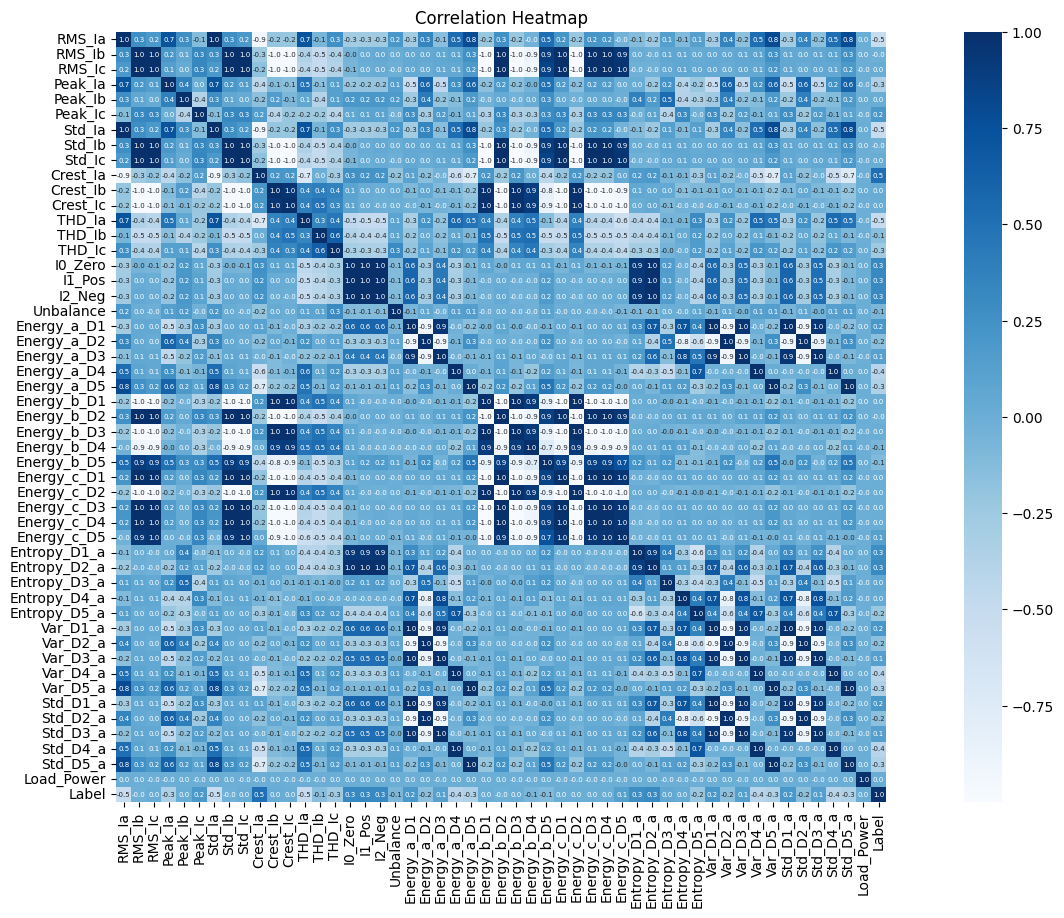

In [4]:
# Correlation Heatmap
plt.figure(figsize = (20,10))
sns.heatmap(dataset.corr(),cbar = True,square = True,fmt = '.1f',annot = True,annot_kws = {'size' : 5},cmap = 'Blues')
plt.title('Correlation Heatmap')
plt.show()

In [5]:
# Train/Test Split
x = dataset.iloc[:,:-1]
y = dataset.iloc[:,-1]
gss = GroupShuffleSplit(n_splits = 1,train_size = 0.81,test_size = 0.19,random_state = 42)
train , test = next(gss.split(x,y,groups))
x_train = x.iloc[train]
x_test = x.iloc[test]
y_train = y.iloc[train]
y_test = y.iloc[test]

In [6]:
# Training Model
xgb = XGBClassifier(n_estimators = 106,learning_rate = 0.01,max_depth = 6,min_child_weight = 3,subsample = 0.8,
                    colsample_bytree = 0.8,gamma = 0.3,reg_alpha = 0.1,reg_lambda = 3,random_state = 42,eval_metric = 'logloss')
model = xgb.fit(x_train,y_train)

In [7]:
# Model Prediction
train_prediction = model.predict(x_train)
test_prediction = model.predict(x_test)

In [8]:
# Model Evaluation
model_evaluation = pd.DataFrame({'Model' : ['XGBoost'],'Accuracy' : [metrics.accuracy_score(y_test,test_prediction)],
                                 'Precision' : [metrics.precision_score(y_test,test_prediction)],
                                 'Recall' : [metrics.recall_score(y_test,test_prediction)],
                                 'F1-Score' : [metrics.f1_score(y_test,test_prediction)]})
model_evaluation.set_index('Model',inplace = True)
print('---------------- Model Evaluation ----------------\n',model_evaluation)

---------------- Model Evaluation ----------------
          Accuracy  Precision    Recall  F1-Score
Model                                           
XGBoost  0.812261   0.805405  0.919753   0.85879


In [9]:
# Group K-Fold Cross-Validation
cv_results = cross_validate(xgb,x,y,cv = GroupKFold(n_splits = 10),groups = groups,
                            scoring = {'accuracy' : 'accuracy','precision' : 'precision','recall' : 'recall','f1' : 'f1'})
print('\n--- Group K-Fold Cross-Validation ---')
for metric_name in ['accuracy','precision','recall','f1'] :
    scores = cv_results[f'test_{metric_name}']
    print(f'{metric_name.capitalize()} Score : 'f'{scores.mean():.2f} ± {scores.std():.2f}')
scores = cross_val_score(xgb,x,y,scoring = 'accuracy',cv = GroupKFold(n_splits = 10),groups = groups)
print('Standard Deviation : {:.2f} %'.format(scores.std() * 100))


--- Group K-Fold Cross-Validation ---
Accuracy Score : 0.77 ± 0.02
Precision Score : 0.79 ± 0.02
Recall Score : 0.86 ± 0.04
F1 Score : 0.82 ± 0.02
Standard Deviation : 1.76 %


In [10]:
# Model Overfitting/Underfitting Check
print('\n--- Overfitting/Underfitting Check ---\nTrain Accuracy Score : {:.0f} %'.format(metrics.accuracy_score(y_train,train_prediction) * 100))
print('Test Accuracy Score : {:.0f} %'.format(metrics.accuracy_score(y_test,test_prediction) * 100))


--- Overfitting/Underfitting Check ---
Train Accuracy Score : 77 %
Test Accuracy Score : 81 %


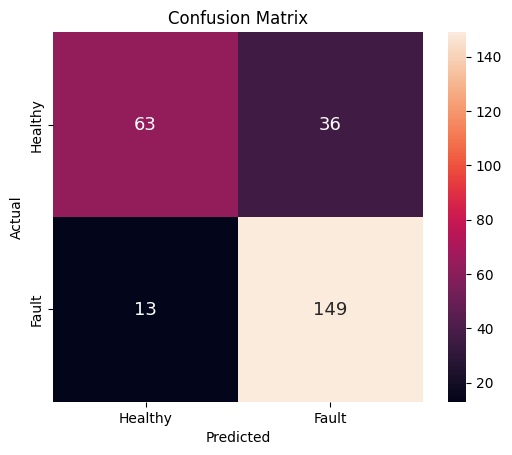

In [11]:
# Confusion Matrix
sns.heatmap(metrics.confusion_matrix(y_test,test_prediction),annot = True,annot_kws = {'size' : 13},
            square = True,fmt = 'd',xticklabels = ['Healthy','Fault'],yticklabels = ['Healthy','Fault'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [15]:
# SHAP Feature Importance
explainer = shap.TreeExplainer(model)
sample_size = min(200,x_test.shape[0])
x_test_sample = x_test[:sample_size]
shap_values = explainer.shap_values(x_test_sample)
mean_abs_shap = np.mean(np.abs(shap_values),axis = 0)
feature_names = x.columns
sorted_idx = np.argsort(mean_abs_shap)[::-1]
print('\n--- SHAP Top 10 Features Importance ---')
for i in range(min(10,len(sorted_idx))) :
    idx = sorted_idx[i]
    print(f'{i+1:2d}. {feature_names[idx]:<20} : {mean_abs_shap[idx]:.4f}')


--- SHAP Top 10 Features Importance ---
 1. RMS_Ia               : 0.5774
 2. Energy_c_D2          : 0.1638
 3. Peak_Ia              : 0.1390
 4. Std_Ia               : 0.1305
 5. I0_Zero              : 0.0694
 6. Crest_Ia             : 0.0317
 7. Energy_b_D3          : 0.0304
 8. THD_Ic               : 0.0231
 9. Load_Power           : 0.0231
10. RMS_Ib               : 0.0171


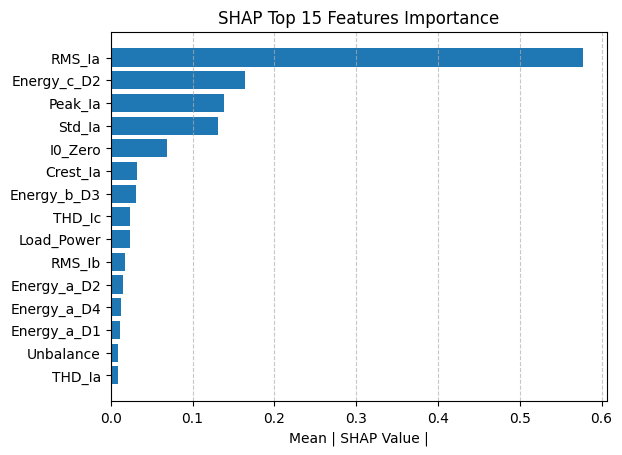

In [26]:
# SHAP Top 15 Features Importance Plot
plt.barh(feature_names[sorted_idx[:15]][::-1],mean_abs_shap[sorted_idx[:15]][::-1])
plt.xlabel('Mean | SHAP Value |')
plt.title('SHAP Top 15 Features Importance')
plt.grid(axis = 'x',linestyle = '--',alpha = 0.7)
plt.show()

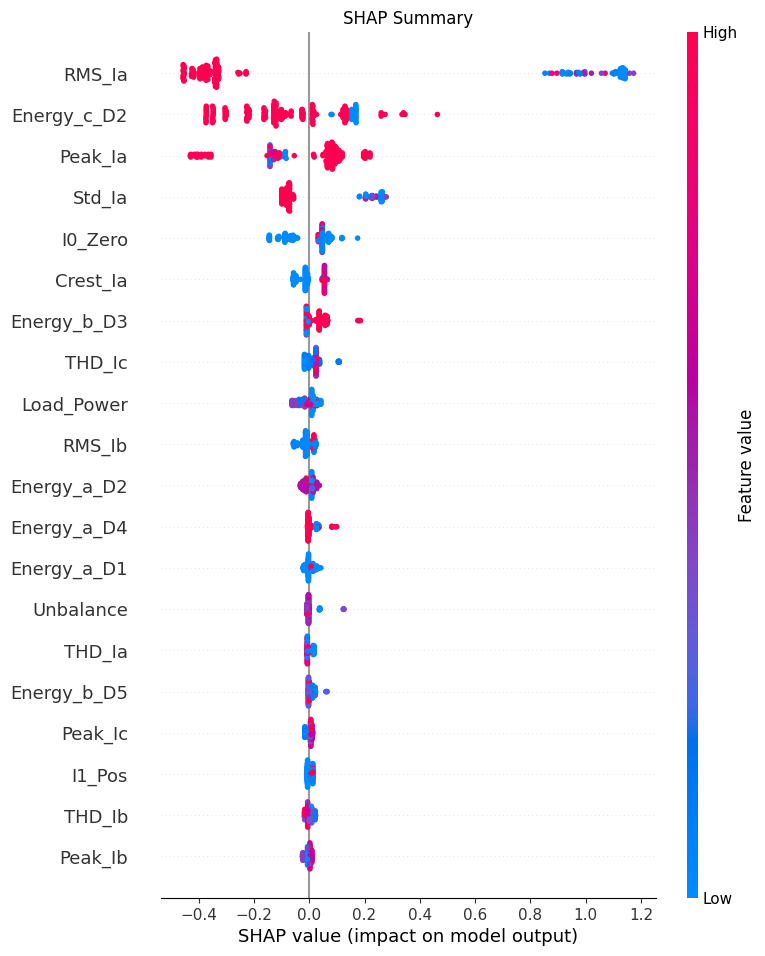

In [27]:
# SHAP Summary Plot
shap.summary_plot(shap_values,x_test_sample,feature_names = feature_names,show = False)
plt.title('SHAP Summary')
plt.show()

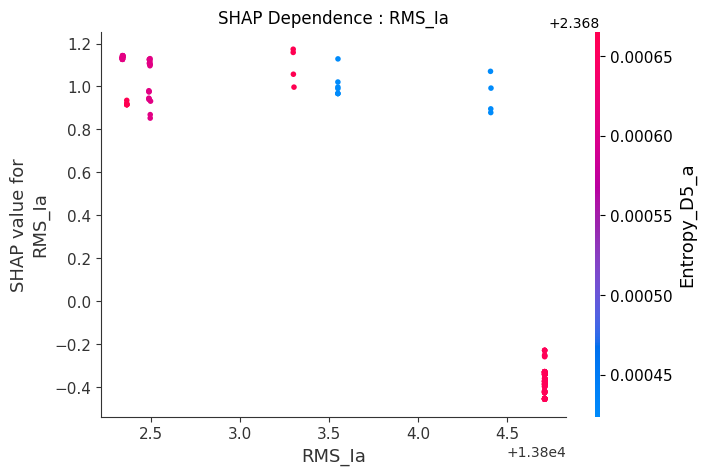

In [28]:
# SHAP Dependence Plot
if len(sorted_idx) >= 2 :
    shap.dependence_plot(sorted_idx[0],shap_values,x_test_sample,feature_names = feature_names,show = False)
    plt.title(f'SHAP Dependence : {feature_names[sorted_idx[0]]}')
plt.show()

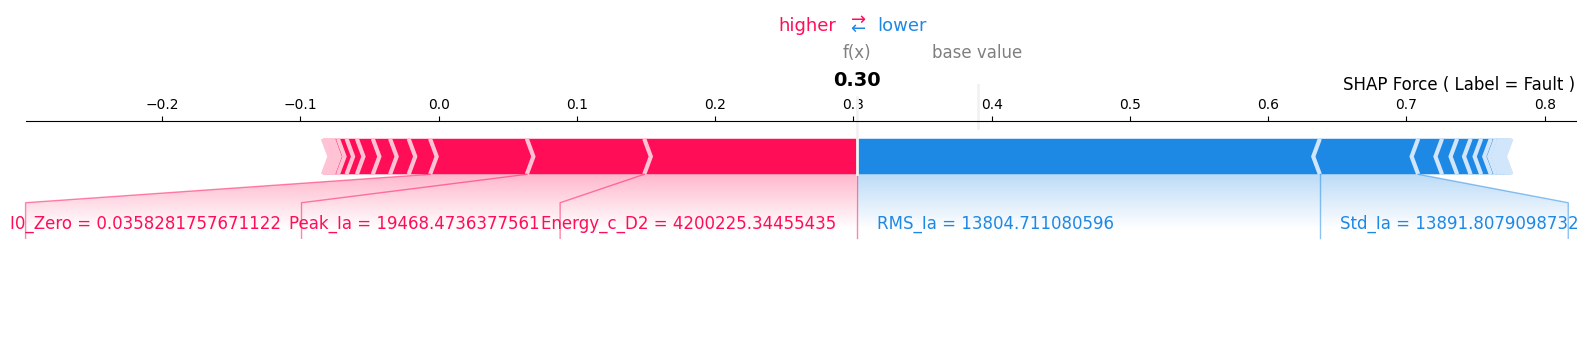

In [43]:
# SHAP Force Plot
fault_idx = np.where(y_test[:sample_size] == 1)[0]
safe_idx = np.where(y_test[:sample_size] == 0)[0]
if len(fault_idx) > 0 and len(safe_idx) > 0 :
    shap.force_plot(explainer.expected_value,shap_values[fault_idx[0],:],x_test_sample.iloc[fault_idx[0],:].values,
                    feature_names = feature_names,matplotlib = True,show = False)
    plt.title(f'SHAP Force ( Label = Fault )',loc = 'right')
else :
    plt.text(0.5,0.5,'Sample Not Found',ha = 'center')
plt.show()

In [44]:
# Saving SHAP Results
with open('SHAP_Results.pkl','wb') as f :
    pickle.dump({'shap_values' : shap_values,'mean_abs_shap' : mean_abs_shap,'sorted_idx' : sorted_idx,
                 'feature_names' : feature_names,'explainer' : explainer},f)

In [45]:
# Final Model
final_xgb = XGBClassifier(n_estimators = 106,learning_rate = 0.01,max_depth = 6,min_child_weight = 3,subsample = 0.8,
                          colsample_bytree = 0.8,gamma = 0.3,reg_alpha = 0.1,reg_lambda = 3,random_state = 42,eval_metric = 'logloss')
final_model = final_xgb.fit(x,y)

In [46]:
# Saving Final Model
with open('XGBoost_Model.pkl','wb') as file :
    pickle.dump(final_model,file)